## Univar Linear Regression

TRAINED: 2001–2023 (inclusive)
PREDICT: 2023-01-01 00:00:00 -> 2024-12-31 23:55:00
Samples — train: 873,457, predict: 210,248
Intercept: 2430.116155
Coefficient (per second): -0.000000524385
Prediction MSE: 73450.17
Prediction R^2: -0.0075


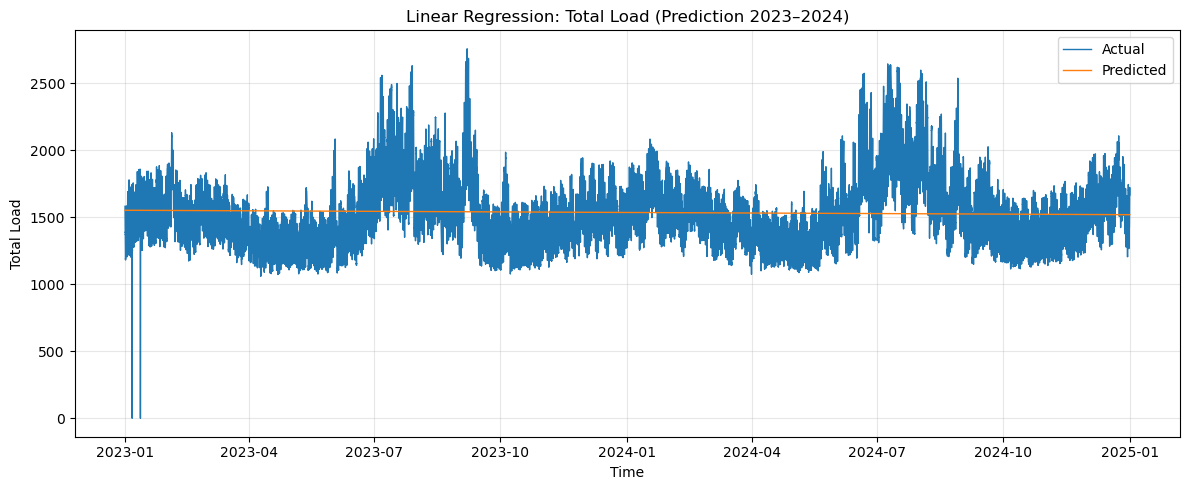

In [ ]:
from pathlib import Path

MASTER_PATH = Path("1_LIB/master/master.parquet")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
quarter = pd.read_parquet(MASTER_PATH)

# Set datetime as index and aggregate by datetime to get total load
quarter['datetime'] = pd.to_datetime(quarter['datetime'], errors='coerce')
quarter = quarter.groupby('datetime')['Load'].sum().to_frame(name='total_load')
quarter = quarter.sort_index()

# Make sure index is timezone-naive
if quarter.index.tz is not None:
    quarter.index = quarter.index.tz_localize(None)

# Hard-coded year windows
train_year_start = 2001
train_year_end = 2023
pred_start_target = pd.Timestamp('2023-01-01 00:00:00')
pred_end_target   = pd.Timestamp('2024-12-31 23:59:59')

# Train window mask (inclusive)
train_mask = (quarter.index.year >= train_year_start) & (quarter.index.year <= train_year_end)

# Prediction window: clamp to available data
available_start_2023 = quarter.index[quarter.index.year == 2023].min()
available_end_2024 = quarter.index[quarter.index.year == 2024].max() if (quarter.index.year == 2024).any() else quarter.index.max()

if pd.isna(available_start_2023):
    raise RuntimeError("No data found for year 2023 in 'quarter'.")
pred_start = max(pred_start_target, available_start_2023)
pred_end   = min(pred_end_target, available_end_2024)

# Slices
quarter_train = quarter.loc[train_mask].copy()
quarter_pred  = quarter.loc[pred_start:pred_end].copy()

# Features: time as seconds since epoch (simple linear trend vs time)
X_train = (quarter_train.index.astype('int64') // 10**9).values.reshape(-1, 1)
y_train = quarter_train['total_load'].values

X_pred  = (quarter_pred.index.astype('int64') // 10**9).values.reshape(-1, 1)
y_true  = quarter_pred['total_load'].values

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on 2023–2024 window
y_pred = model.predict(X_pred)

# Metrics on prediction window
mse = mean_squared_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)

print("TRAINED: 2001–2023 (inclusive)")
print(f"PREDICT: {pred_start} -> {pred_end}")
print(f"Samples — train: {len(X_train):,}, predict: {len(X_pred):,}")
print(f"Intercept: {float(model.intercept_):.6f}")
print(f"Coefficient (per second): {float(np.ravel(model.coef_)[0]):.12f}")
print(f"Prediction MSE: {mse:.2f}")
print(f"Prediction R^2: {r2:.4f}")

# Plot predictions vs actual for the prediction window
plt.figure(figsize=(12, 5))
plt.plot(quarter_pred.index, y_true, label='Actual', color='tab:blue', linewidth=1)
plt.plot(quarter_pred.index, y_pred, label='Predicted', color='tab:orange', linewidth=1)
plt.title('Linear Regression: Total Load (Prediction 2023–2024)')
plt.xlabel('Time')
plt.ylabel('Total Load')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: store predictions for later use
lr_pred_2023_2024 = pd.DataFrame(
    {'actual': y_true, 'pred': y_pred},
    index=quarter_pred.index
)

Prediction window summary
  Range: 2023-01-01 00:00:00 -> 2024-12-31 23:55:00  (n=210,248)
  Actual:
    mean=1543.843, std=270.002, min=0.000, max=2758.475
  Pred:
    mean=1536.513, std=9.564, min=1519.946, max=1553.065
  Errors:
    MAE=207.418, MSE=73450.169, RMSE=271.017, MAPE=13.355%
    Bias (mean residual)=-7.330
  Fit:
    R^2=-0.0075, Pearson r=-0.0783, Spearman ρ=-0.0669

Worst 5 days by RMSE:

Worst 5 days by RMSE:


,RMSE
datetime,
2024-07-10,798.392850
2024-07-16,772.763465
2023-09-06,771.964530
2023-09-07,766.761493
2024-08-02,755.074150



Monthly RMSE (head):


,RMSE
datetime,
2023-01,169.396383
2023-02,172.065776
2023-03,161.335272
2023-04,258.617360
2023-05,265.674923



Daily MAPE (head):


,MAPE_%
datetime,
2023-01-01,15.951844
2023-01-02,11.969633
2023-01-03,11.052392
2023-01-04,9.249007
2023-01-05,9.921233


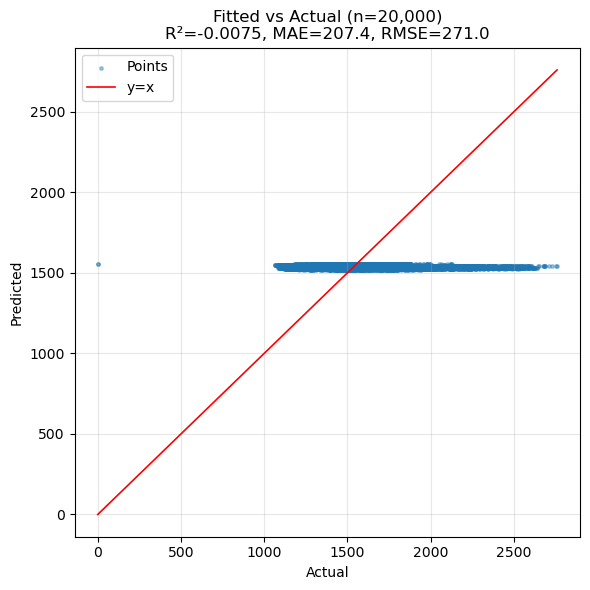

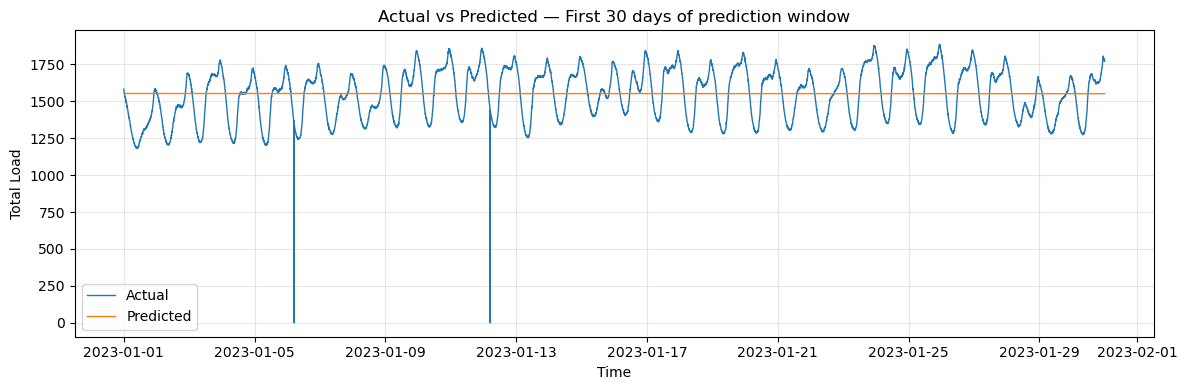

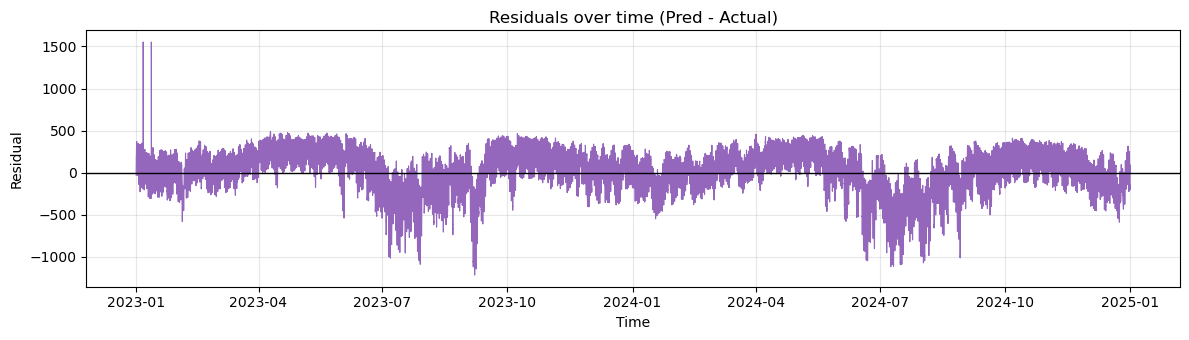

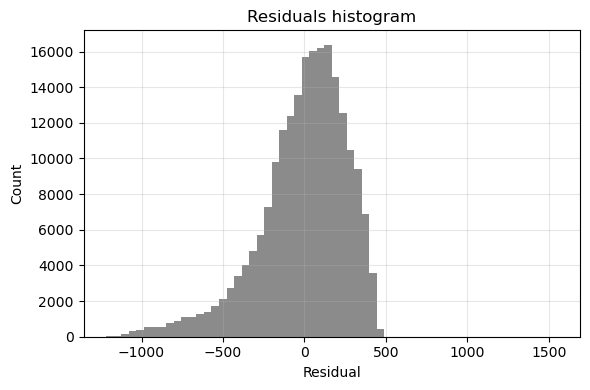

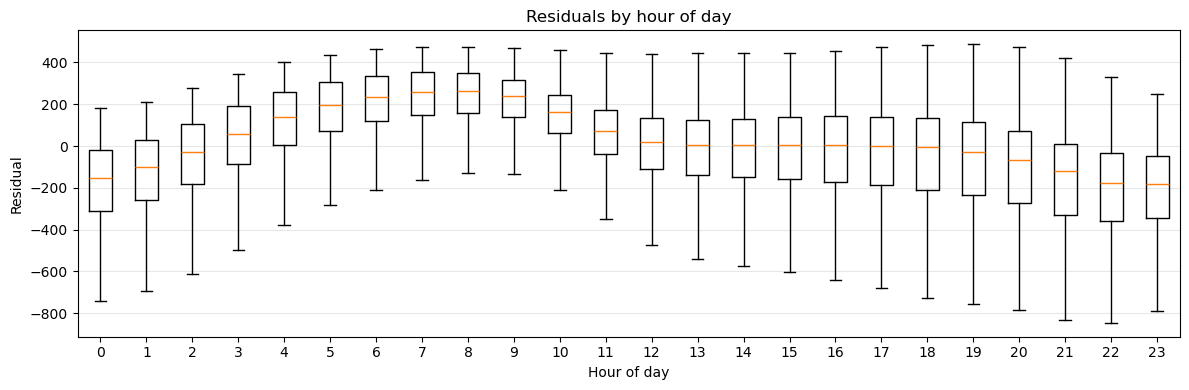


Prediction summary dict available as 'prediction_summary'.


In [7]:
# New cell — summary statistics and diagnostics (fitted vs actual)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Try to assemble predictions/actuals from existing variables
if 'lr_pred_2023_2024' in globals():
    df_pred = lr_pred_2023_2024.copy()
    if not isinstance(df_pred.index, pd.DatetimeIndex):
        df_pred.index = pd.to_datetime(df_pred.index, errors='coerce')
elif all(v in globals() for v in ['quarter_pred', 'y_true', 'y_pred']):
    df_pred = pd.DataFrame(
        {'actual': np.asarray(y_true).ravel(), 'pred': np.asarray(y_pred).ravel()},
        index=quarter_pred.index
    )
    if not isinstance(df_pred.index, pd.DatetimeIndex):
        df_pred.index = pd.to_datetime(df_pred.index, errors='coerce')
else:
    raise RuntimeError("No predictions found. Run the previous regression cell to create 'lr_pred_2023_2024' or 'quarter_pred/y_true/y_pred'.")

# Drop any NA rows for clean metrics/plots
df_pred = df_pred.dropna(subset=['actual', 'pred']).sort_index()
if df_pred.empty:
    raise RuntimeError("No valid rows after dropping NaNs in 'actual'/'pred'.")

# Basic residuals
df_pred['resid'] = df_pred['pred'] - df_pred['actual']

# Summary statistics
n = len(df_pred)
start_ts = df_pred.index.min()
end_ts = df_pred.index.max()
y_mean = df_pred['actual'].mean()
y_std  = df_pred['actual'].std()
y_min  = df_pred['actual'].min()
y_max  = df_pred['actual'].max()
p_mean = df_pred['pred'].mean()
p_std  = df_pred['pred'].std()
p_min  = df_pred['pred'].min()
p_max  = df_pred['pred'].max()

mae = np.mean(np.abs(df_pred['resid']))
mse = np.mean(df_pred['resid']**2)
rmse = np.sqrt(mse)
# Avoid division by zero in MAPE
mask_nonzero = df_pred['actual'] != 0
mape = (np.abs((df_pred.loc[mask_nonzero, 'actual'] - df_pred.loc[mask_nonzero, 'pred']) / df_pred.loc[mask_nonzero, 'actual']).mean() * 100.0) if mask_nonzero.any() else np.nan
bias = df_pred['resid'].mean()

# R^2 and correlations
# R^2 over the full prediction window:
ss_res = np.sum(df_pred['resid']**2)
ss_tot = np.sum((df_pred['actual'] - y_mean)**2)
r2 = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan
pearson = np.corrcoef(df_pred['actual'], df_pred['pred'])[0,1] if n > 2 else np.nan
spearman = df_pred['actual'].corr(df_pred['pred'], method='spearman') if n > 2 else np.nan

# Print summary
print("Prediction window summary")
print(f"  Range: {start_ts} -> {end_ts}  (n={n:,})")
print("  Actual:")
print(f"    mean={y_mean:.3f}, std={y_std:.3f}, min={y_min:.3f}, max={y_max:.3f}")
print("  Pred:")
print(f"    mean={p_mean:.3f}, std={p_std:.3f}, min={p_min:.3f}, max={p_max:.3f}")
print("  Errors:")
print(f"    MAE={mae:.3f}, MSE={mse:.3f}, RMSE={rmse:.3f}, MAPE={mape:.3f}%")
print(f"    Bias (mean residual)={bias:.3f}")
print("  Fit:")
print(f"    R^2={r2:.4f}, Pearson r={pearson:.4f}, Spearman ρ={spearman:.4f}")

# Daily and monthly aggregates for diagnostics
daily_rmse = df_pred.groupby(df_pred.index.normalize())['resid'].apply(lambda r: np.sqrt(np.mean(r**2)))
monthly_rmse = df_pred.groupby(df_pred.index.to_period('M'))['resid'].apply(lambda r: np.sqrt(np.mean(r**2)))
daily_mape = df_pred.groupby(df_pred.index.normalize()).apply(
    lambda g: (np.abs((g.loc[g['actual']!=0, 'actual'] - g.loc[g['actual']!=0, 'pred']) / g.loc[g['actual']!=0, 'actual']).mean() * 100.0)
    if (g['actual']!=0).any() else np.nan
)

print("\nWorst 5 days by RMSE:")
display(daily_rmse.sort_values(ascending=False).head(5).to_frame('RMSE'))
print("\nMonthly RMSE (head):")
display(monthly_rmse.head().to_frame('RMSE'))
print("\nDaily MAPE (head):")
display(daily_mape.head().to_frame('MAPE_%'))

# ========== Plots ==========

# 1) Fitted vs Actual (scatter) with 45-degree line
plt.figure(figsize=(6,6))
# Subsample if very large for readability
max_points = 20000
if len(df_pred) > max_points:
    sampled = df_pred.sample(max_points, random_state=42)
else:
    sampled = df_pred
plt.scatter(sampled['actual'], sampled['pred'], s=6, alpha=0.4, color='tab:blue', label='Points')
lims_min = float(min(sampled['actual'].min(), sampled['pred'].min()))
lims_max = float(max(sampled['actual'].max(), sampled['pred'].max()))
plt.plot([lims_min, lims_max], [lims_min, lims_max], color='red', linewidth=1.2, label='y=x')
plt.title(f'Fitted vs Actual (n={len(sampled):,})\nR²={r2:.4f}, MAE={mae:.1f}, RMSE={rmse:.1f}')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Time series overlay (first ~30 days of prediction window for visibility)
start_view = df_pred.index.min()
end_view = start_view + pd.Timedelta(days=30)
view = df_pred.loc[start_view:end_view]

plt.figure(figsize=(12,4))
plt.plot(view.index, view['actual'], label='Actual', color='tab:blue', linewidth=1)
plt.plot(view.index, view['pred'],   label='Predicted', color='tab:orange', linewidth=1)
plt.title('Actual vs Predicted — First 30 days of prediction window')
plt.xlabel('Time')
plt.ylabel('Total Load')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Residuals over time
plt.figure(figsize=(12,3.5))
plt.plot(df_pred.index, df_pred['resid'], color='tab:purple', linewidth=0.8)
plt.axhline(0, color='black', linewidth=1)
plt.title('Residuals over time (Pred - Actual)')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Residuals distribution
plt.figure(figsize=(6,4))
plt.hist(df_pred['resid'], bins=60, color='tab:gray', alpha=0.9)
plt.title('Residuals histogram')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Residuals by hour-of-day (boxplot)
if isinstance(df_pred.index, pd.DatetimeIndex):
    hour_of_day = df_pred.index.hour
    # To keep simple and avoid seaborn, use matplotlib boxplot grouped by hour
    data_by_hour = [df_pred.loc[hour_of_day == h, 'resid'].values for h in range(24)]
    plt.figure(figsize=(12,4))
    plt.boxplot(data_by_hour, positions=range(24), showfliers=False)
    plt.title('Residuals by hour of day')
    plt.xlabel('Hour of day')
    plt.ylabel('Residual')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Expose key outputs for reuse
prediction_summary = {
    'n': n, 'start': start_ts, 'end': end_ts,
    'y_mean': y_mean, 'y_std': y_std, 'y_min': y_min, 'y_max': y_max,
    'p_mean': p_mean, 'p_std': p_std, 'p_min': p_min, 'p_max': p_max,
    'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE_%': mape, 'Bias': bias,
    'R2': r2, 'Pearson_r': pearson, 'Spearman_rho': spearman
}
print("\nPrediction summary dict available as 'prediction_summary'.")

## Stepwise Linear Regression
Using forward selection with p-value < 0.05 and maximizing adjusted R²

In [8]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Reload full dataset with all features
df_full = pd.read_parquet(MASTER_PATH)
df_full['datetime'] = pd.to_datetime(df_full['datetime'], errors='coerce')

# Remove timezone if present
if df_full['datetime'].dt.tz is not None:
    df_full['datetime'] = df_full['datetime'].dt.tz_localize(None)

df_full = df_full.set_index('datetime').sort_index()

# Select numeric features (exclude target 'Load' and non-numeric columns)
numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
if 'Load' in numeric_cols:
    numeric_cols.remove('Load')

# Handle missing values - drop rows with NaN in Load or features
df_clean = df_full[numeric_cols + ['Load']].dropna()

print(f"Original dataset: {len(df_full):,} rows")
print(f"After removing NaN: {len(df_clean):,} rows")
print(f"Available features: {len(numeric_cols)}")
print(f"Feature names: {numeric_cols[:10]}...") # Show first 10

# Split into train/test using same time windows
train_mask_step = (df_clean.index.year >= train_year_start) & (df_clean.index.year <= train_year_end)
test_mask_step = (df_clean.index >= pred_start) & (df_clean.index <= pred_end)

X_train_full = df_clean.loc[train_mask_step, numeric_cols].copy()
y_train_full = df_clean.loc[train_mask_step, 'Load'].copy()

X_test_full = df_clean.loc[test_mask_step, numeric_cols].copy()
y_test_full = df_clean.loc[test_mask_step, 'Load'].copy()

print(f"\nTrain set: {len(X_train_full):,} samples")
print(f"Test set: {len(X_test_full):,} samples")

Original dataset: 1,057,304 rows
After removing NaN: 409,061 rows
Available features: 40
Feature names: ['latitude [degrees_north]', 'longitude [degrees_east]', 'elevation [feet]', 'temp_2m [degF]', 'temp_9m [degF]', 'apparent_temperature [degF]', 'relative_humidity [percent]', 'dewpoint [degF]', 'precip_incremental [inch]', 'precip_local [inch]']...

Train set: 318,008 samples
Test set: 109,341 samples


In [12]:
# Forward Stepwise Selection with Feature Type Constraint
# Criteria: p-value < 0.05 and maximize adjusted R²
# Constraint: Only one feature per feature type (e.g., one soil_moisture depth)

def get_feature_base(feature_name):
    """
    Extract the base feature type from a feature name.
    E.g., 'soil_moisture_25cm [m^3/m^3]' -> 'soil_moisture'
    """
    # Remove units in brackets
    base = feature_name.split('[')[0].strip()
    # Remove depth/height indicators (numbers followed by cm, m, etc.)
    import re
    base = re.sub(r'_\d+cm|_\d+m', '', base)
    return base

def forward_selection_unique_types(X, y, significance_level=0.05):
    """
    Forward stepwise selection based on p-values and adjusted R²
    Only allows one feature per feature type (e.g., one soil_moisture, one temp)
    """
    initial_features = X.columns.tolist()
    best_features = []
    selected_types = set()
    
    print("Starting Forward Stepwise Selection (Unique Feature Types Only)...")
    print(f"Significance level: {significance_level}")
    print(f"Total features available: {len(initial_features)}\n")
    
    iteration = 0
    best_adj_r2 = -np.inf
    
    while len(initial_features) > 0:
        iteration += 1
        remaining_features = list(set(initial_features) - set(best_features))
        
        if len(remaining_features) == 0:
            break
            
        new_pval = pd.Series(index=remaining_features, dtype=float)
        new_adj_r2 = pd.Series(index=remaining_features, dtype=float)
        
        # Test each remaining feature
        for new_column in remaining_features:
            # Check if this feature type is already selected
            feature_type = get_feature_base(new_column)
            if feature_type in selected_types:
                new_pval[new_column] = 1.0
                new_adj_r2[new_column] = -np.inf
                continue
            
            features_to_test = best_features + [new_column]
            X_temp = sm.add_constant(X[features_to_test])
            
            try:
                model_temp = sm.OLS(y, X_temp).fit()
                new_pval[new_column] = model_temp.pvalues[new_column]
                new_adj_r2[new_column] = model_temp.rsquared_adj
            except:
                new_pval[new_column] = 1.0
                new_adj_r2[new_column] = -np.inf
        
        # Find features with p-value < significance_level
        valid_features = new_pval[new_pval < significance_level]
        
        if len(valid_features) == 0:
            print(f"\nIteration {iteration}: No features meet p-value criterion. Stopping.")
            break
        
        # Among valid features, select the one that maximizes adjusted R²
        best_feature = new_adj_r2[valid_features.index].idxmax()
        best_pval = new_pval[best_feature]
        best_adj_r2_new = new_adj_r2[best_feature]
        
        # Check if adjusted R² improved
        if best_adj_r2_new > best_adj_r2:
            best_features.append(best_feature)
            feature_type = get_feature_base(best_feature)
            selected_types.add(feature_type)
            best_adj_r2 = best_adj_r2_new
            print(f"Iteration {iteration}: Added '{best_feature}' (type: {feature_type}) | p-value: {best_pval:.6f} | Adj R²: {best_adj_r2_new:.6f}")
        else:
            print(f"\nIteration {iteration}: No improvement in Adj R². Stopping.")
            break
        
        # Stop if we've added too many features (prevents overfitting)
        if len(best_features) >= 30:
            print(f"\nReached maximum of 30 features. Stopping.")
            break
    
    print(f"\n{'='*60}")
    print(f"Forward Selection Complete!")
    print(f"Selected {len(best_features)} features")
    print(f"Final Adjusted R²: {best_adj_r2:.6f}")
    print(f"{'='*60}\n")
    
    return best_features

# Run forward selection with unique feature types constraint
selected_features = forward_selection_unique_types(X_train_full, y_train_full, significance_level=0.05)

print("Selected Features:")
for i, feat in enumerate(selected_features, 1):
    feature_type = get_feature_base(feat)
    print(f"  {i}. {feat} (type: {feature_type})")

Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.201777
Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.201777
Iteration 2: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.231694
Iteration 2: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.231694
Iteration 3: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.250594
Iteration 3: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.250594
Iteration 4: Added 'precip_local [inch]' (type: precip_local) | p-value: 0.000000 | Adj R²: 0.273835
Iteration 4: Added 'precip_local [inch]' (type: precip_local) | p-value: 0.000000 | Adj R²: 0.273835
Iteration 5: Added 'avg_wind_speed_sonic [mile/hr]' (type: avg_wind_

In [13]:
# Build final model with selected features
X_train_selected = sm.add_constant(X_train_full[selected_features])
X_test_selected = sm.add_constant(X_test_full[selected_features])

# Fit the final model
final_model = sm.OLS(y_train_full, X_train_selected).fit()

print("="*70)
print("FINAL STEPWISE LINEAR REGRESSION MODEL SUMMARY")
print("="*70)
print(final_model.summary())
print("\n")

# Make predictions on test set
y_pred_stepwise = final_model.predict(X_test_selected)

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_step = mean_absolute_error(y_test_full, y_pred_stepwise)
mse_step = mean_squared_error(y_test_full, y_pred_stepwise)
rmse_step = np.sqrt(mse_step)
r2_step = r2_score(y_test_full, y_pred_stepwise)

# Calculate MAPE
mask_nonzero_step = y_test_full != 0
mape_step = (np.abs((y_test_full[mask_nonzero_step] - y_pred_stepwise[mask_nonzero_step]) / y_test_full[mask_nonzero_step]).mean() * 100.0) if mask_nonzero_step.any() else np.nan

print("="*70)
print("TEST SET PERFORMANCE METRICS")
print("="*70)
print(f"Test samples: {len(y_test_full):,}")
print(f"MAE:  {mae_step:.3f}")
print(f"MSE:  {mse_step:.3f}")
print(f"RMSE: {rmse_step:.3f}")
print(f"R²:   {r2_step:.4f}")
print(f"MAPE: {mape_step:.3f}%")
print("="*70)

# Compare with simple linear regression
print("\nCOMPARISON WITH SIMPLE LINEAR REGRESSION:")
print(f"Simple Linear Regression - R²: {r2:.4f}, RMSE: {rmse:.3f}, MAPE: {mape:.3f}%")
print(f"Stepwise Regression      - R²: {r2_step:.4f}, RMSE: {rmse_step:.3f}, MAPE: {mape_step:.3f}%")
print(f"Improvement in R²:   {r2_step - r2:.4f}")
print(f"Improvement in RMSE: {rmse - rmse_step:.3f}")
print(f"Improvement in MAPE: {mape - mape_step:.3f}%")

FINAL STEPWISE LINEAR REGRESSION MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                   Load   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     6229.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:37:40   Log-Likelihood:            -2.0815e+06
No. Observations:              318008   AIC:                         4.163e+06
Df Residuals:                  317984   BIC:                         4.163e+06
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

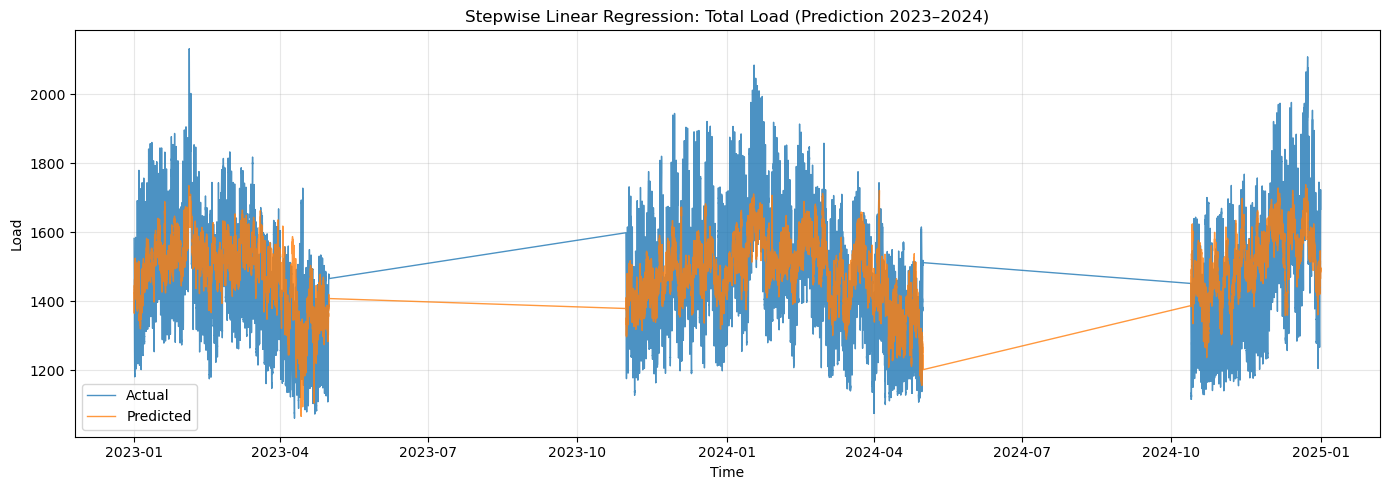

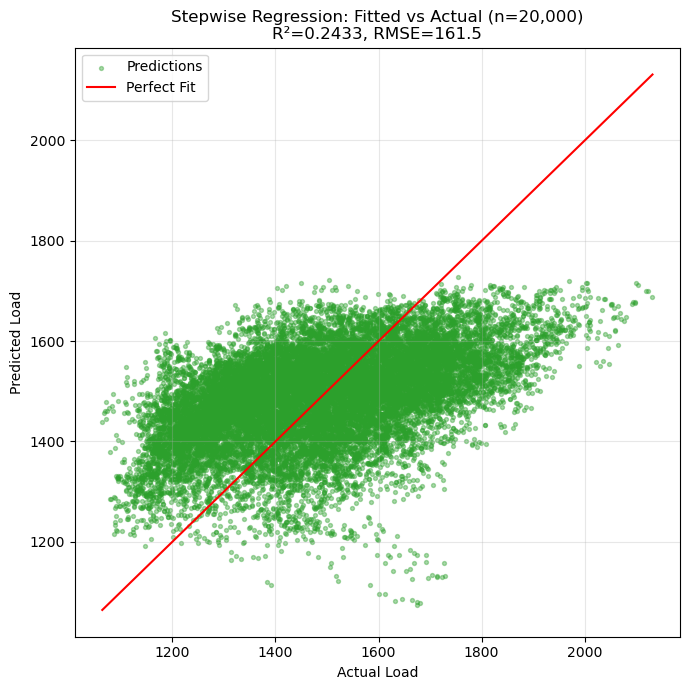

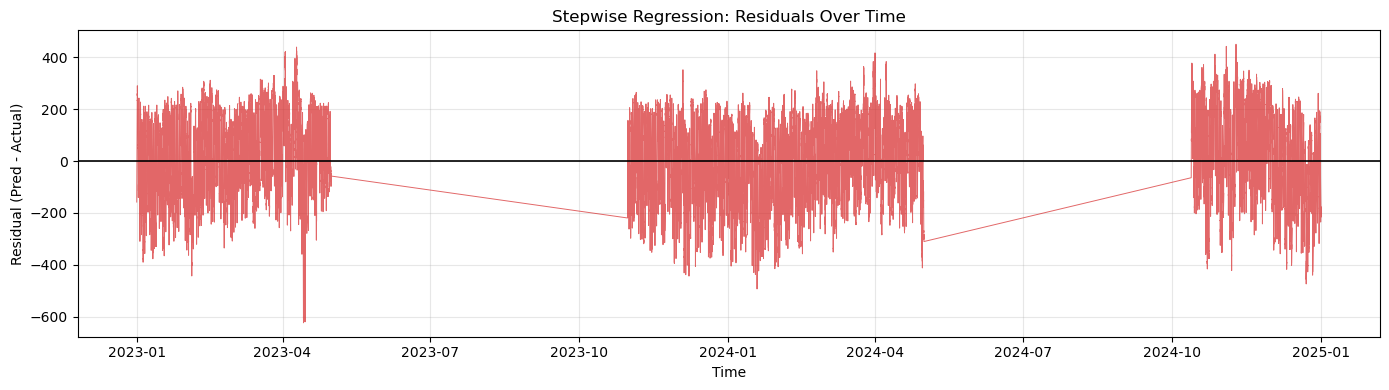

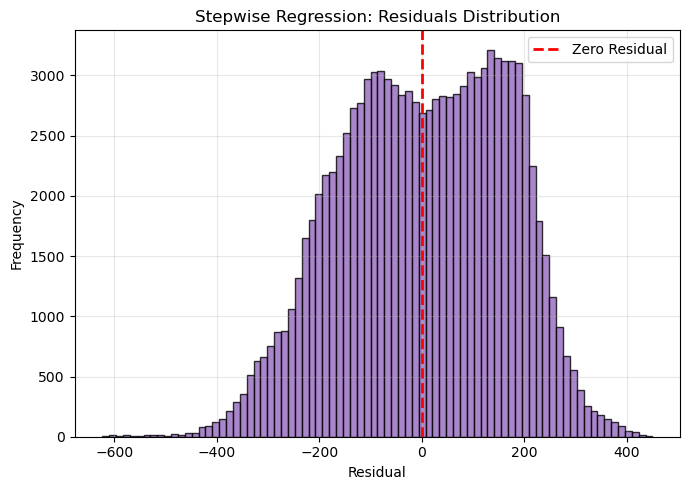

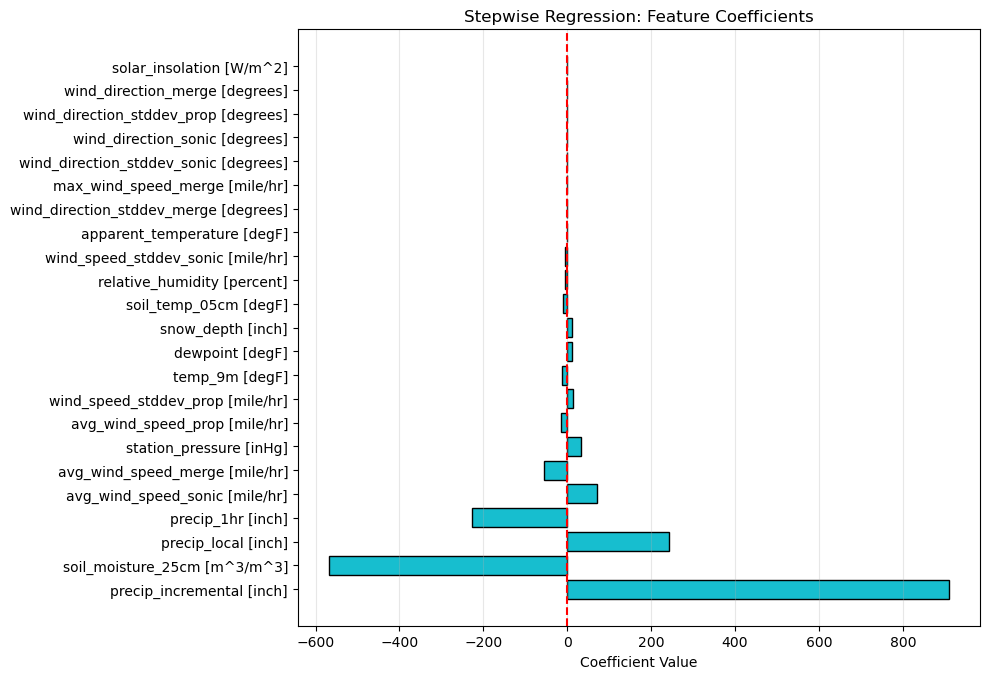


Top 10 Most Important Features (by absolute coefficient):
                         Feature  Coefficient
       precip_incremental [inch]   910.027574
    soil_moisture_25cm [m^3/m^3]  -568.379197
             precip_local [inch]   241.360365
               precip_1hr [inch]  -226.864321
  avg_wind_speed_sonic [mile/hr]    69.780936
  avg_wind_speed_merge [mile/hr]   -55.321223
         station_pressure [inHg]    32.644876
   avg_wind_speed_prop [mile/hr]   -14.699486
wind_speed_stddev_prop [mile/hr]    13.897945
                  temp_9m [degF]   -12.314316


In [14]:
# Visualization of Stepwise Regression Results

# Create predictions dataframe
df_pred_stepwise = pd.DataFrame({
    'actual': y_test_full.values,
    'pred': y_pred_stepwise.values
}, index=y_test_full.index)

df_pred_stepwise['resid'] = df_pred_stepwise['pred'] - df_pred_stepwise['actual']

# 1) Actual vs Predicted Time Series
plt.figure(figsize=(14, 5))
plt.plot(df_pred_stepwise.index, df_pred_stepwise['actual'], label='Actual', color='tab:blue', linewidth=1, alpha=0.8)
plt.plot(df_pred_stepwise.index, df_pred_stepwise['pred'], label='Predicted', color='tab:orange', linewidth=1, alpha=0.8)
plt.title('Stepwise Linear Regression: Total Load (Prediction 2023–2024)')
plt.xlabel('Time')
plt.ylabel('Load')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Fitted vs Actual Scatter Plot
plt.figure(figsize=(7, 7))
max_points_vis = 20000
if len(df_pred_stepwise) > max_points_vis:
    sampled_step = df_pred_stepwise.sample(max_points_vis, random_state=42)
else:
    sampled_step = df_pred_stepwise

plt.scatter(sampled_step['actual'], sampled_step['pred'], s=8, alpha=0.4, color='tab:green', label='Predictions')
lims_min_step = float(min(sampled_step['actual'].min(), sampled_step['pred'].min()))
lims_max_step = float(max(sampled_step['actual'].max(), sampled_step['pred'].max()))
plt.plot([lims_min_step, lims_max_step], [lims_min_step, lims_max_step], color='red', linewidth=1.5, label='Perfect Fit')
plt.title(f'Stepwise Regression: Fitted vs Actual (n={len(sampled_step):,})\nR²={r2_step:.4f}, RMSE={rmse_step:.1f}')
plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3) Residuals Over Time
plt.figure(figsize=(14, 4))
plt.plot(df_pred_stepwise.index, df_pred_stepwise['resid'], color='tab:red', linewidth=0.7, alpha=0.7)
plt.axhline(0, color='black', linewidth=1.2)
plt.title('Stepwise Regression: Residuals Over Time')
plt.xlabel('Time')
plt.ylabel('Residual (Pred - Actual)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Residuals Distribution
plt.figure(figsize=(7, 5))
plt.hist(df_pred_stepwise['resid'], bins=80, color='tab:purple', alpha=0.8, edgecolor='black')
plt.axvline(0, color='red', linewidth=2, linestyle='--', label='Zero Residual')
plt.title('Stepwise Regression: Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Feature Importance (Coefficients)
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': final_model.params[selected_features].values,
    'Abs_Coefficient': np.abs(final_model.params[selected_features].values)
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, max(6, len(selected_features) * 0.3)))
plt.barh(range(len(coef_df)), coef_df['Coefficient'], color='tab:cyan', edgecolor='black')
plt.yticks(range(len(coef_df)), coef_df['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Stepwise Regression: Feature Coefficients')
plt.axvline(0, color='red', linewidth=1.5, linestyle='--')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (by absolute coefficient):")
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

## Stepwise Regression Across Different Time Scales
Compare model performance at different temporal resolutions

In [15]:
# Test stepwise regression at different time scales
# Aggregate data and run the same stepwise approach

time_scales = {
    '5min': '5min',
    '15min': '15min', 
    '30min': '30min',
    '1hour': '1H',
    '3hour': '3H',
    '6hour': '6H',
    '12hour': '12H',
    '1day': '1D'
}

results_by_timescale = {}

print("="*80)
print("RUNNING STEPWISE REGRESSION ACROSS DIFFERENT TIME SCALES")
print("="*80)

for scale_name, resample_freq in time_scales.items():
    print(f"\n{'='*80}")
    print(f"TIME SCALE: {scale_name}")
    print(f"{'='*80}")
    
    # Aggregate data at this time scale
    df_agg = df_clean.resample(resample_freq).agg({
        **{col: 'mean' for col in numeric_cols},
        'Load': 'sum'
    }).dropna()
    
    print(f"Aggregated data: {len(df_agg):,} samples")
    
    # Split into train/test
    train_mask_scale = (df_agg.index.year >= train_year_start) & (df_agg.index.year <= train_year_end)
    test_mask_scale = (df_agg.index >= pred_start) & (df_agg.index <= pred_end)
    
    X_train_scale = df_agg.loc[train_mask_scale, numeric_cols].copy()
    y_train_scale = df_agg.loc[train_mask_scale, 'Load'].copy()
    
    X_test_scale = df_agg.loc[test_mask_scale, numeric_cols].copy()
    y_test_scale = df_agg.loc[test_mask_scale, 'Load'].copy()
    
    print(f"Train: {len(X_train_scale):,} samples, Test: {len(X_test_scale):,} samples")
    
    # Run forward selection (limit iterations for speed)
    try:
        # Use fewer features for faster computation
        selected_features_scale = forward_selection_unique_types(
            X_train_scale, 
            y_train_scale, 
            significance_level=0.05
        )
        
        # Build and evaluate model
        X_train_sel = sm.add_constant(X_train_scale[selected_features_scale])
        X_test_sel = sm.add_constant(X_test_scale[selected_features_scale])
        
        model_scale = sm.OLS(y_train_scale, X_train_sel).fit()
        y_pred_scale = model_scale.predict(X_test_sel)
        
        # Calculate metrics
        mae_scale = mean_absolute_error(y_test_scale, y_pred_scale)
        mse_scale = mean_squared_error(y_test_scale, y_pred_scale)
        rmse_scale = np.sqrt(mse_scale)
        r2_scale = r2_score(y_test_scale, y_pred_scale)
        
        mask_nz = y_test_scale != 0
        mape_scale = (np.abs((y_test_scale[mask_nz] - y_pred_scale[mask_nz]) / y_test_scale[mask_nz]).mean() * 100.0) if mask_nz.any() else np.nan
        
        # Store results
        results_by_timescale[scale_name] = {
            'n_features': len(selected_features_scale),
            'adj_r2_train': model_scale.rsquared_adj,
            'r2_test': r2_scale,
            'rmse': rmse_scale,
            'mae': mae_scale,
            'mape': mape_scale,
            'n_train': len(X_train_scale),
            'n_test': len(X_test_scale),
            'features': selected_features_scale
        }
        
        print(f"\nRESULTS:")
        print(f"  Features selected: {len(selected_features_scale)}")
        print(f"  Train Adj R²: {model_scale.rsquared_adj:.4f}")
        print(f"  Test R²:  {r2_scale:.4f}")
        print(f"  RMSE:     {rmse_scale:.3f}")
        print(f"  MAE:      {mae_scale:.3f}")
        print(f"  MAPE:     {mape_scale:.3f}%")
        
    except Exception as e:
        print(f"ERROR: {str(e)}")
        results_by_timescale[scale_name] = {
            'error': str(e)
        }

print(f"\n{'='*80}")
print("COMPLETED ALL TIME SCALES")
print(f"{'='*80}")

RUNNING STEPWISE REGRESSION ACROSS DIFFERENT TIME SCALES

TIME SCALE: 5min
Aggregated data: 409,061 samples
Train: 318,008 samples, Test: 109,341 samples
Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Aggregated data: 409,061 samples
Train: 318,008 samples, Test: 109,341 samples
Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.201777
Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.201777
Iteration 2: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.231694
Iteration 2: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.231694
Iteration 3: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.250594
Iteratio

C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\5980307.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg = df_clean.resample(resample_freq).agg({


Aggregated data: 34,189 samples
Train: 26,585 samples, Test: 9,138 samples
Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.182477
Iteration 2: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.210853
Iteration 3: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.229761
Iteration 2: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.210853
Iteration 3: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.229761
Iteration 4: Added 'precip_local [inch]' (type: precip_local) | p-value: 0.000000 | Adj R²: 0.248282
Iteration 5: Added 'avg_wind_speed_sonic [mile/hr]' (type: avg_wind_speed_sonic) | p-value: 0.000000 | Adj R²: 0.257310
Iteration 4: Added 'precip_local [inch]' (type: precip_local) | p-value: 0

C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\5980307.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg = df_clean.resample(resample_freq).agg({


Aggregated data: 11,424 samples
Train: 8,883 samples, Test: 3,050 samples
Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.174072
Iteration 2: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.202215
Iteration 3: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.222777
Iteration 4: Added 'precip_local [inch]' (type: precip_local) | p-value: 0.000000 | Adj R²: 0.236766
Iteration 5: Added 'max_wind_speed_prop [mile/hr]' (type: max_wind_speed_prop) | p-value: 0.000000 | Adj R²: 0.246361
Iteration 3: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.222777
Iteration 4: Added 'precip_local [inch]' (type: precip_local) | p-value: 0.000000 | Adj R²: 0.236766
Iteration 5: Added 'max_wind_speed_prop [mile/hr]' (type: max_wind_sp

C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\5980307.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg = df_clean.resample(resample_freq).agg({


Aggregated data: 5,727 samples
Train: 4,453 samples, Test: 1,528 samples
Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.175686
Iteration 2: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.209381
Iteration 3: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.230394
Iteration 4: Added 'wind_speed_stddev_prop [mile/hr]' (type: wind_speed_stddev_prop) | p-value: 0.000000 | Adj R²: 0.247307
Iteration 3: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.230394
Iteration 4: Added 'wind_speed_stddev_prop [mile/hr]' (type: wind_speed_stddev_prop) | p-value: 0.000000 | Adj R²: 0.247307
Iteration 5: Added 'solar_insolation [W/m^2]' (type: solar_insolation) | p-value: 0.000000 | Adj R²: 0.256179
Iteration 6: Added 'precip_local

C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\5980307.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg = df_clean.resample(resample_freq).agg({


Aggregated data: 2,872 samples
Train: 2,232 samples, Test: 766 samples
Starting Forward Stepwise Selection (Unique Feature Types Only)...
Significance level: 0.05
Total features available: 40

Iteration 1: Added 'soil_temp_05cm [degF]' (type: soil_temp) | p-value: 0.000000 | Adj R²: 0.218171
Iteration 2: Added 'solar_insolation [W/m^2]' (type: solar_insolation) | p-value: 0.000000 | Adj R²: 0.264277
Iteration 3: Added 'apparent_temperature [degF]' (type: apparent_temperature) | p-value: 0.000000 | Adj R²: 0.332220
Iteration 4: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.357992
Iteration 5: Added 'dewpoint [degF]' (type: dewpoint) | p-value: 0.000000 | Adj R²: 0.368760
Iteration 3: Added 'apparent_temperature [degF]' (type: apparent_temperature) | p-value: 0.000000 | Adj R²: 0.332220
Iteration 4: Added 'soil_moisture_25cm [m^3/m^3]' (type: soil_moisture) | p-value: 0.000000 | Adj R²: 0.357992
Iteration 5: Added 'dewpoint [degF]' (type: dewp


STEPWISE REGRESSION PERFORMANCE ACROSS TIME SCALES


,Time Scale,N Features,Train Adj R²,Test R²,RMSE,MAE,MAPE (%),Train Samples,Test Samples
0,5min,23,0.310540,0.243290,161.475683,135.579980,9.292027,318008,109341
1,15min,23,0.292428,0.221842,503.218531,413.135151,9.660137,106210,36514
2,30min,21,0.289769,0.219098,1007.696121,825.342376,9.750544,53137,18265
3,1hour,20,0.287596,0.212045,2036.448385,1648.602329,10.161145,26585,9138
4,3hour,22,0.281197,0.215371,5982.861708,4800.750101,9.488720,8883,3050
5,6hour,17,0.297778,0.223013,11333.776667,8635.878379,8.860358,4453,1528
6,12hour,10,0.393380,0.277142,20203.828545,14259.471067,7.168693,2232,766
7,1day,5,0.411186,0.277533,33065.373016,23878.513193,5.918928,1120,383


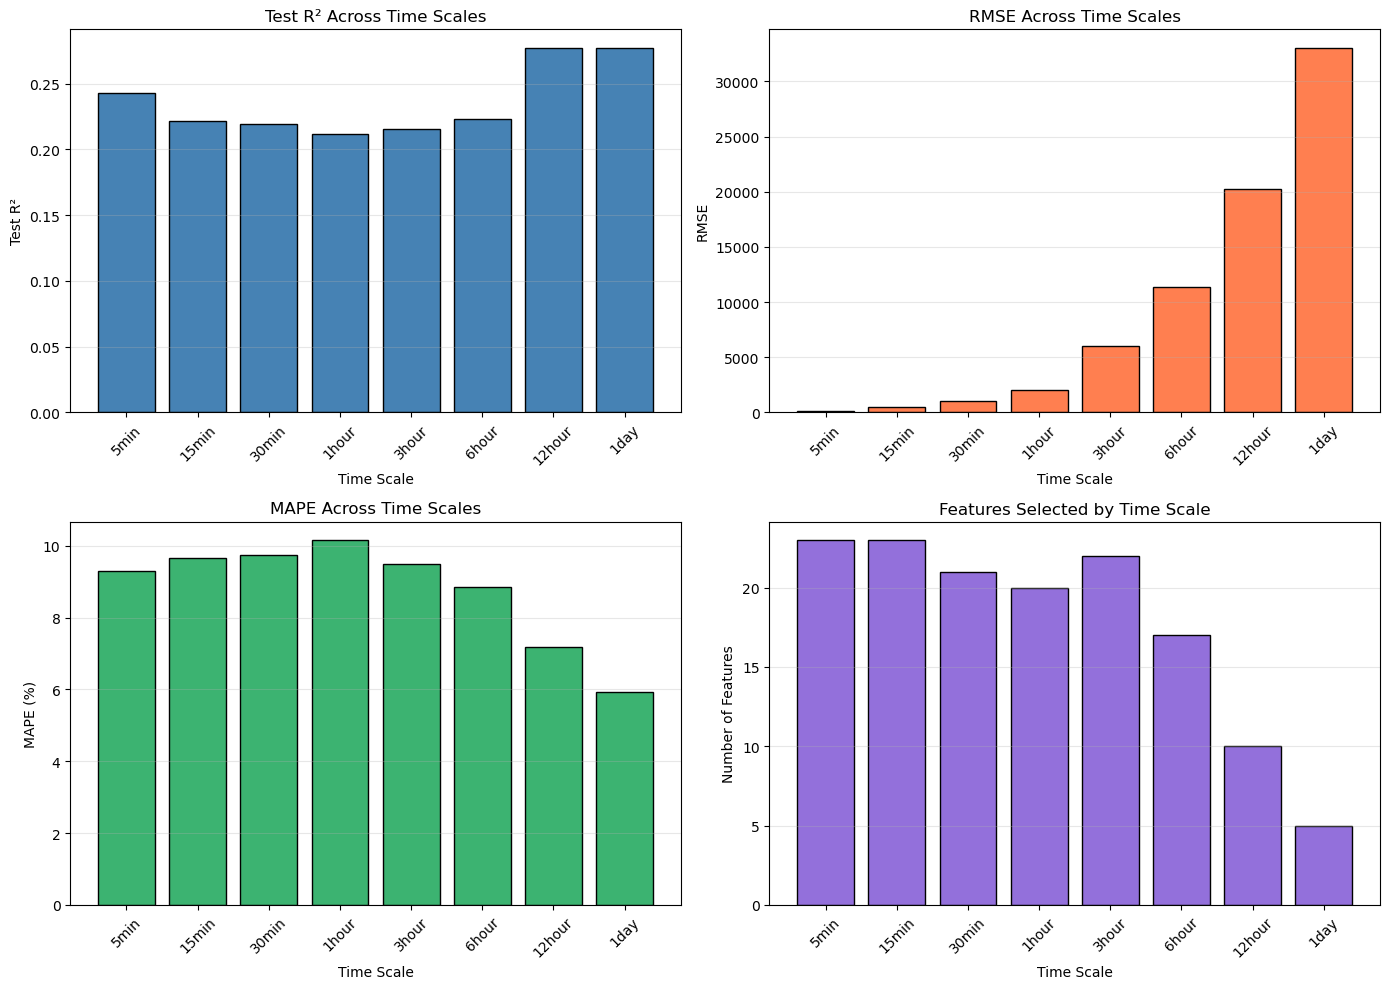


BEST PERFORMING TIME SCALES
Best Test R²:  1day (R² = 0.2775)
Best RMSE:     5min (RMSE = 161.476)
Best MAPE:     1day (MAPE = 5.919%)


In [16]:
# Visualize results across time scales

# Create comparison dataframe
comparison_data = []
for scale, results in results_by_timescale.items():
    if 'error' not in results:
        comparison_data.append({
            'Time Scale': scale,
            'N Features': results['n_features'],
            'Train Adj R²': results['adj_r2_train'],
            'Test R²': results['r2_test'],
            'RMSE': results['rmse'],
            'MAE': results['mae'],
            'MAPE (%)': results['mape'],
            'Train Samples': results['n_train'],
            'Test Samples': results['n_test']
        })

comparison_df = pd.DataFrame(comparison_data)

# Display table
print("\n" + "="*100)
print("STEPWISE REGRESSION PERFORMANCE ACROSS TIME SCALES")
print("="*100)
display(comparison_df)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Test R² by time scale
ax1 = axes[0, 0]
ax1.bar(comparison_df['Time Scale'], comparison_df['Test R²'], color='steelblue', edgecolor='black')
ax1.set_xlabel('Time Scale')
ax1.set_ylabel('Test R²')
ax1.set_title('Test R² Across Time Scales')
ax1.grid(alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# 2) RMSE by time scale
ax2 = axes[0, 1]
ax2.bar(comparison_df['Time Scale'], comparison_df['RMSE'], color='coral', edgecolor='black')
ax2.set_xlabel('Time Scale')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE Across Time Scales')
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# 3) MAPE by time scale
ax3 = axes[1, 0]
ax3.bar(comparison_df['Time Scale'], comparison_df['MAPE (%)'], color='mediumseagreen', edgecolor='black')
ax3.set_xlabel('Time Scale')
ax3.set_ylabel('MAPE (%)')
ax3.set_title('MAPE Across Time Scales')
ax3.grid(alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45)

# 4) Number of features selected
ax4 = axes[1, 1]
ax4.bar(comparison_df['Time Scale'], comparison_df['N Features'], color='mediumpurple', edgecolor='black')
ax4.set_xlabel('Time Scale')
ax4.set_ylabel('Number of Features')
ax4.set_title('Features Selected by Time Scale')
ax4.grid(alpha=0.3, axis='y')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Find best performing time scale
best_r2_idx = comparison_df['Test R²'].idxmax()
best_rmse_idx = comparison_df['RMSE'].idxmin()
best_mape_idx = comparison_df['MAPE (%)'].idxmin()

print("\n" + "="*100)
print("BEST PERFORMING TIME SCALES")
print("="*100)
print(f"Best Test R²:  {comparison_df.loc[best_r2_idx, 'Time Scale']} (R² = {comparison_df.loc[best_r2_idx, 'Test R²']:.4f})")
print(f"Best RMSE:     {comparison_df.loc[best_rmse_idx, 'Time Scale']} (RMSE = {comparison_df.loc[best_rmse_idx, 'RMSE']:.3f})")
print(f"Best MAPE:     {comparison_df.loc[best_mape_idx, 'Time Scale']} (MAPE = {comparison_df.loc[best_mape_idx, 'MAPE (%)']:.3f}%)")
print("="*100)

## Univariate vs Multivariate Comparison
Compare simple time-based regression against multivariate stepwise regression across time scales

In [18]:
# Run univariate time-based regression across all time scales for comparison

univariate_results = {}

print("="*80)
print("RUNNING UNIVARIATE TIME-BASED REGRESSION ACROSS TIME SCALES")
print("="*80)

for scale_name, resample_freq in time_scales.items():
    print(f"\n{'='*80}")
    print(f"TIME SCALE: {scale_name}")
    print(f"{'='*80}")
    
    # Aggregate data at this time scale (just need Load and datetime)
    df_agg_univar = df_clean.resample(resample_freq).agg({'Load': 'sum'}).dropna()
    
    print(f"Aggregated data: {len(df_agg_univar):,} samples")
    
    # Split into train/test
    train_mask_univar = (df_agg_univar.index.year >= train_year_start) & (df_agg_univar.index.year <= train_year_end)
    test_mask_univar = (df_agg_univar.index >= pred_start) & (df_agg_univar.index <= pred_end)
    
    df_train_univar = df_agg_univar.loc[train_mask_univar].copy()
    df_test_univar = df_agg_univar.loc[test_mask_univar].copy()
    
    print(f"Train: {len(df_train_univar):,} samples, Test: {len(df_test_univar):,} samples")
    
    try:
        # Univariate: time as seconds since epoch
        X_train_univar = (df_train_univar.index.astype('int64') // 10**9).values.reshape(-1, 1)
        y_train_univar = df_train_univar['Load'].values
        
        X_test_univar = (df_test_univar.index.astype('int64') // 10**9).values.reshape(-1, 1)
        y_test_univar = df_test_univar['Load'].values
        
        # Fit simple linear regression
        model_univar = LinearRegression()
        model_univar.fit(X_train_univar, y_train_univar)
        
        # Predict
        y_pred_univar = model_univar.predict(X_test_univar)
        
        # Calculate metrics
        mae_univar = mean_absolute_error(y_test_univar, y_pred_univar)
        mse_univar = mean_squared_error(y_test_univar, y_pred_univar)
        rmse_univar = np.sqrt(mse_univar)
        r2_univar = r2_score(y_test_univar, y_pred_univar)
        
        mask_nz_univar = y_test_univar != 0
        mape_univar = (np.abs((y_test_univar[mask_nz_univar] - y_pred_univar[mask_nz_univar]) / y_test_univar[mask_nz_univar]).mean() * 100.0) if mask_nz_univar.any() else np.nan
        
        # Store results
        univariate_results[scale_name] = {
            'r2_test': r2_univar,
            'rmse': rmse_univar,
            'mae': mae_univar,
            'mape': mape_univar,
            'n_train': len(X_train_univar),
            'n_test': len(X_test_univar)
        }
        
        print(f"\nRESULTS:")
        print(f"  Test R²:  {r2_univar:.4f}")
        print(f"  RMSE:     {rmse_univar:.3f}")
        print(f"  MAE:      {mae_univar:.3f}")
        print(f"  MAPE:     {mape_univar:.3f}%")
        
    except Exception as e:
        print(f"ERROR: {str(e)}")
        univariate_results[scale_name] = {
            'error': str(e)
        }

print(f"\n{'='*80}")
print("COMPLETED UNIVARIATE ANALYSIS")
print(f"{'='*80}")

RUNNING UNIVARIATE TIME-BASED REGRESSION ACROSS TIME SCALES

TIME SCALE: 5min
Aggregated data: 789,696 samples
Train: 649,728 samples, Test: 210,528 samples

RESULTS:
  Test R²:  -0.0346
  RMSE:     767.003
  MAE:      745.683
  MAPE:     57.145%

TIME SCALE: 15min
Aggregated data: 263,232 samples
Train: 216,576 samples, Test: 70,176 samples

RESULTS:
  Test R²:  -0.0347
  RMSE:     2298.690
  MAE:      2234.025
  MAPE:     57.055%

TIME SCALE: 30min
Aggregated data: 131,616 samples
Train: 108,288 samples, Test: 35,088 samples

RESULTS:
  Test R²:  -0.0347
  RMSE:     4595.376
  MAE:      4466.791
  MAPE:     57.091%

TIME SCALE: 1hour
Aggregated data: 65,808 samples
Train: 54,144 samples, Test: 17,544 samples

RESULTS:
  Test R²:  -0.0348
  RMSE:     9187.198
  MAE:      8930.737
  MAPE:     57.226%

TIME SCALE: 3hour
Aggregated data: 21,936 samples
Train: 18,048 samples, Test: 5,848 samples

RESULTS:
  Test R²:  -0.0349
  RMSE:     27510.363
  MAE:      26755.518
  MAPE:     56.996%


C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\2329031339.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg_univar = df_clean.resample(resample_freq).agg({'Load': 'sum'}).dropna()
C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\2329031339.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg_univar = df_clean.resample(resample_freq).agg({'Load': 'sum'}).dropna()
C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\2329031339.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg_univar = df_clean.resample(resample_freq).agg({'Load': 'sum'}).dropna()
C:\Users\Matt\AppData\Local\Temp\ipykernel_24920\2329031339.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_agg_univar = df_clean.resample(resample_freq).agg({'Load': 'sum'}).dropna()



UNIVARIATE vs MULTIVARIATE STEPWISE REGRESSION COMPARISON


,Time Scale,Univariate R²,Multivariate R²,R² Improvement,Univariate RMSE,Multivariate RMSE,RMSE Improvement,Univariate MAPE (%),Multivariate MAPE (%),MAPE Improvement (%),N Features
0,5min,-0.034624,0.243290,0.277914,767.002829,161.475683,605.527147,57.144939,9.292027,47.852912,23
1,15min,-0.034696,0.221842,0.256538,2298.690164,503.218531,1795.471633,57.054876,9.660137,47.394739,23
2,30min,-0.034727,0.219098,0.253826,4595.375823,1007.696121,3587.679703,57.090961,9.750544,47.340417,21
3,1hour,-0.034755,0.212045,0.246800,9187.198100,2036.448385,7150.749716,57.225998,10.161145,47.064852,20
4,3hour,-0.034889,0.215371,0.250260,27510.363092,5982.861708,21527.501384,56.995534,9.488720,47.506813,22
5,6hour,-0.035134,0.223013,0.258147,54835.110379,11333.776667,43501.333712,57.041705,8.860358,48.181347,17
6,12hour,-0.035472,0.277142,0.312614,109161.213648,20203.828545,88957.385103,56.859076,7.168693,49.690384,10
7,1day,-0.035787,0.277533,0.313320,217427.288799,33065.373016,184361.915783,57.054318,5.918928,51.135390,5


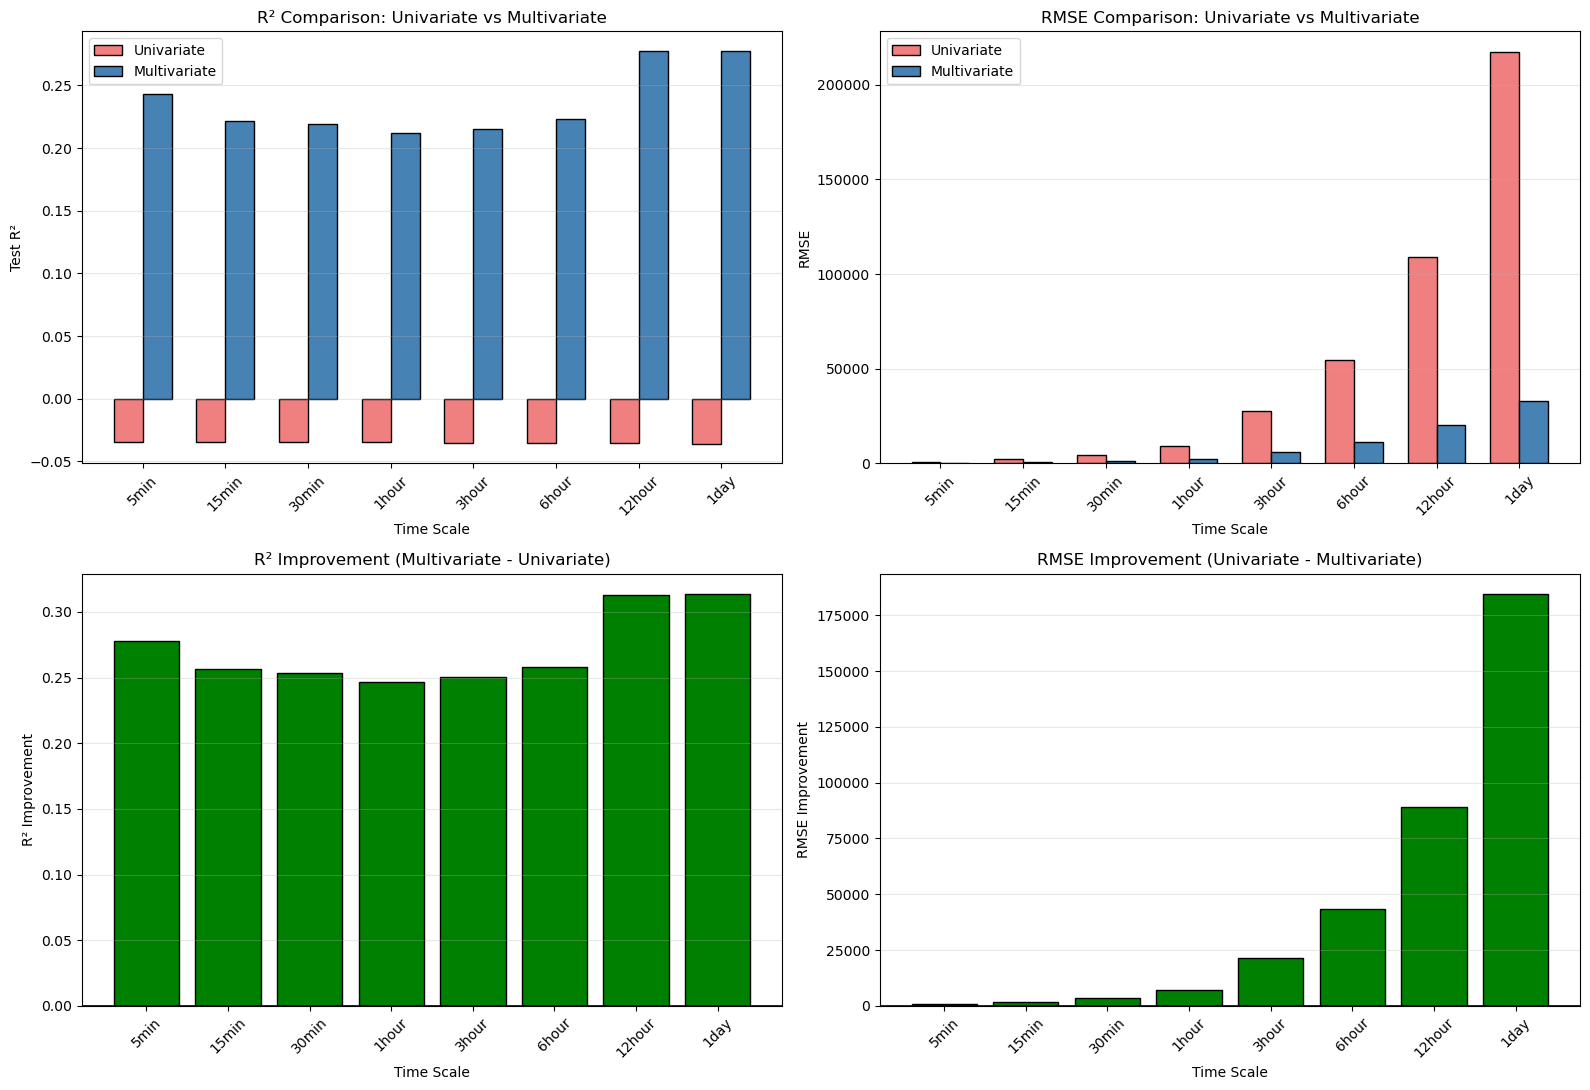


IMPROVEMENT SUMMARY
Average R² Improvement:    0.2712
Average RMSE Improvement:  43935.946
Average MAPE Improvement:  48.271%

Best R² Improvement:       1day (0.3133)
Best RMSE Improvement:     1day (184361.916)
Best MAPE Improvement:     1day (51.135%)

PERCENTAGE IMPROVEMENT
5min     - R²:   802.7% | RMSE:   78.9% | MAPE:   83.7% | Features: 23
15min    - R²:   739.4% | RMSE:   78.1% | MAPE:   83.1% | Features: 23
30min    - R²:   730.9% | RMSE:   78.1% | MAPE:   82.9% | Features: 21
1hour    - R²:   710.1% | RMSE:   77.8% | MAPE:   82.2% | Features: 20
3hour    - R²:   717.3% | RMSE:   78.3% | MAPE:   83.4% | Features: 22
6hour    - R²:   734.7% | RMSE:   79.3% | MAPE:   84.5% | Features: 17
12hour   - R²:   881.3% | RMSE:   81.5% | MAPE:   87.4% | Features: 10
1day     - R²:   875.5% | RMSE:   84.8% | MAPE:   89.6% | Features:  5


In [20]:
# Compare Univariate vs Multivariate across time scales

# Build comparison dataframe
comparison_both = []

for scale in time_scales.keys():
    if scale in univariate_results and 'error' not in univariate_results[scale]:
        if scale in results_by_timescale and 'error' not in results_by_timescale[scale]:
            univar = univariate_results[scale]
            multivar = results_by_timescale[scale]
            
            comparison_both.append({
                'Time Scale': scale,
                'Univariate R²': univar['r2_test'],
                'Multivariate R²': multivar['r2_test'],
                'R² Improvement': multivar['r2_test'] - univar['r2_test'],
                'Univariate RMSE': univar['rmse'],
                'Multivariate RMSE': multivar['rmse'],
                'RMSE Improvement': univar['rmse'] - multivar['rmse'],
                'Univariate MAPE (%)': univar['mape'],
                'Multivariate MAPE (%)': multivar['mape'],
                'MAPE Improvement (%)': univar['mape'] - multivar['mape'],
                'N Features': multivar['n_features']
            })

comparison_both_df = pd.DataFrame(comparison_both)

# Display table
print("\n" + "="*120)
print("UNIVARIATE vs MULTIVARIATE STEPWISE REGRESSION COMPARISON")
print("="*120)
display(comparison_both_df)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1) R² Comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(comparison_both_df))
width = 0.35
ax1.bar(x_pos - width/2, comparison_both_df['Univariate R²'], width, label='Univariate', color='lightcoral', edgecolor='black')
ax1.bar(x_pos + width/2, comparison_both_df['Multivariate R²'], width, label='Multivariate', color='steelblue', edgecolor='black')
ax1.set_xlabel('Time Scale')
ax1.set_ylabel('Test R²')
ax1.set_title('R² Comparison: Univariate vs Multivariate')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_both_df['Time Scale'], rotation=45)
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# 2) RMSE Comparison
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, comparison_both_df['Univariate RMSE'], width, label='Univariate', color='lightcoral', edgecolor='black')
ax2.bar(x_pos + width/2, comparison_both_df['Multivariate RMSE'], width, label='Multivariate', color='steelblue', edgecolor='black')
ax2.set_xlabel('Time Scale')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE Comparison: Univariate vs Multivariate')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_both_df['Time Scale'], rotation=45)
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

# 3) R² Improvement
ax3 = axes[1, 0]
colors = ['green' if x > 0 else 'red' for x in comparison_both_df['R² Improvement']]
ax3.bar(comparison_both_df['Time Scale'], comparison_both_df['R² Improvement'], color=colors, edgecolor='black')
ax3.axhline(0, color='black', linewidth=1.2)
ax3.set_xlabel('Time Scale')
ax3.set_ylabel('R² Improvement')
ax3.set_title('R² Improvement (Multivariate - Univariate)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(alpha=0.3, axis='y')

# 4) RMSE Improvement
ax4 = axes[1, 1]
colors = ['green' if x > 0 else 'red' for x in comparison_both_df['RMSE Improvement']]
ax4.bar(comparison_both_df['Time Scale'], comparison_both_df['RMSE Improvement'], color=colors, edgecolor='black')
ax4.axhline(0, color='black', linewidth=1.2)
ax4.set_xlabel('Time Scale')
ax4.set_ylabel('RMSE Improvement')
ax4.set_title('RMSE Improvement (Univariate - Multivariate)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*120)
print("IMPROVEMENT SUMMARY")
print("="*120)
print(f"Average R² Improvement:    {comparison_both_df['R² Improvement'].mean():.4f}")
print(f"Average RMSE Improvement:  {comparison_both_df['RMSE Improvement'].mean():.3f}")
print(f"Average MAPE Improvement:  {comparison_both_df['MAPE Improvement (%)'].mean():.3f}%")
print(f"\nBest R² Improvement:       {comparison_both_df.loc[comparison_both_df['R² Improvement'].idxmax(), 'Time Scale']} ({comparison_both_df['R² Improvement'].max():.4f})")
print(f"Best RMSE Improvement:     {comparison_both_df.loc[comparison_both_df['RMSE Improvement'].idxmax(), 'Time Scale']} ({comparison_both_df['RMSE Improvement'].max():.3f})")
print(f"Best MAPE Improvement:     {comparison_both_df.loc[comparison_both_df['MAPE Improvement (%)'].idxmax(), 'Time Scale']} ({comparison_both_df['MAPE Improvement (%)'].max():.3f}%)")
print("="*120)

# Additional: Percentage improvement
print("\n" + "="*120)
print("PERCENTAGE IMPROVEMENT")
print("="*120)
for _, row in comparison_both_df.iterrows():
    r2_pct = (row['R² Improvement'] / abs(row['Univariate R²']) * 100) if row['Univariate R²'] != 0 else np.inf
    rmse_pct = (row['RMSE Improvement'] / row['Univariate RMSE'] * 100) if row['Univariate RMSE'] != 0 else 0
    mape_pct = (row['MAPE Improvement (%)'] / row['Univariate MAPE (%)'] * 100) if row['Univariate MAPE (%)'] != 0 else 0
    
    print(f"{row['Time Scale']:8s} - R²: {r2_pct:7.1f}% | RMSE: {rmse_pct:6.1f}% | MAPE: {mape_pct:6.1f}% | Features: {row['N Features']:2.0f}")
print("="*120)